In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vidhi0405/cybattt-cyberattack-tweets/cybattt.csv


# Baseline Model - TF-IDF with Logistic Regression
**Explainable AI (XAI) for Cybersecurity Threat Classification on Social Media**

This notebook establishes the classical machine-learning baseline for the CybAttT cybersecurity tweet classification task. The baseline uses TF-IDF text representation with Logistic Regression to classify tweets into the three target classes: `Not_News`, `Normal_News`, and `High_Risk_News`.

The notebook implements the data preparation and baseline-modelling stages of the proposed methodology. Its primary purpose is to establish a reproducible and interpretable reference model against which the fine-tuned BERT model will subsequently be evaluated. The project proposal identifies TF-IDF + Logistic Regression as the baseline and macro-F1 as the principal classification metric because of the substantial class imbalance in the dataset. 

The experimental pipeline consists of dataset loading and integrity checks, fixed stratified partitioning, TF-IDF-specific preprocessing, validation-based hyperparameter selection, representation and preprocessing ablation, final model estimation, held-out test evaluation, bootstrap uncertainty quantification, error analysis, reproducibility artefact generation, coefficient-based interpretation, and a post-hoc similarity audit.

The independent test partition is kept frozen throughout model selection and is used only for final evaluation. The resulting predictions, metadata, partition checksum and coefficient rankings are retained as reproducibility artefacts for the subsequent BERT experiment.

This notebook therefore establishes the TF-IDF baseline required for RQ1 and provides the interpretable lexical reference required for the later cross-model analysis in RQ4. Token-level SHAP explanations and AOPC faithfulness evaluation are conducted in the companion BERT notebook rather than in this baseline notebook.

## 0. Environment and Reproducibility

In [2]:
import sys
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Environment information
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Seed   :", SEED)

Python : 3.12.13
NumPy  : 2.0.2
Pandas : 2.3.3
scikit-learn: 1.6.1
Seed   : 42


## 1. Data Loading and Corpus Description

The study uses CybAttT (Lughbi, Mars and Almotairi, 2024, *Data*, 9(3), 39), a purpose-built corpus of 36,080 cyberattack-related tweets annotated into three classes: `Not_News` (general chatter), `Normal_News` (routine cybersecurity reporting) and `High_Risk_News` (urgent, high-severity threat reporting). A fourth category, labelled `Exluded` in the source data, contains nine tweets on which the annotators could not agree. These observations do not provide a reliable ground-truth class and are therefore removed before modelling.

The following cell loads the corpus from the author's Kaggle mirror of the original public release. Dataset integrity is checked before modelling, including verification of the expected columns and class labels. The nine `Exluded` observations are removed, the dataframe index is reset to provide contiguous row identifiers for the index-based partitioning used later, and the three analytical classes are encoded consistently as integers: `Not_News = 0`, `Normal_News = 1`, and `High_Risk_News = 2`.

The resulting corpus summary reports the number and proportion of observations in each analytical class. These counts are retained as a reference for subsequent stratified partitioning and evaluation.

In [3]:
DATA_PATH = '/kaggle/input/datasets/vidhi0405/cybattt-cyberattack-tweets/cybattt.csv'

# Load the CybAttT corpus
df = pd.read_csv(DATA_PATH)

# Basic dataset integrity checks
required_columns = {'majority'}
missing_columns = required_columns.difference(df.columns)

assert not missing_columns, (
    f"Required column(s) missing from dataset: {missing_columns}"
)

print(f"Original corpus size: {len(df):,}")
print(f"Original columns: {df.shape[1]:,}")

# Verify the source labels before removing excluded observations
source_label_counts = (
    df['majority']
    .value_counts(dropna=False)
    .rename_axis('Label')
    .reset_index(name='Count')
)

display(source_label_counts)

# Remove the dataset's own 'Exluded' rows.
# These observations have no agreed ground-truth class.
n_before = len(df)

excluded_count = (df['majority'] == 'Exluded').sum()

assert excluded_count == 9, (
    f"Expected 9 'Exluded' rows, found {excluded_count}."
)

df = (
    df[df['majority'] != 'Exluded']
    .reset_index(drop=True)
)

n_after = len(df)

print(
    f"\nRows retained: {n_before:,} -> {n_after:,}"
)
print(
    f"'Exluded' rows removed: {n_before - n_after:,}"
)

# Fixed integer label encoding
LABEL_MAP = {
    'Not_News': 0,
    'Normal_News': 1,
    'High_Risk_News': 2
}

ID2LABEL = {
    value: key
    for key, value in LABEL_MAP.items()
}

CLASS_NAMES = [
    'Not_News',
    'Normal_News',
    'High_Risk_News'
]

# Verify that only the three analytical classes remain
remaining_labels = set(df['majority'].dropna().unique())

assert remaining_labels == set(CLASS_NAMES), (
    f"Unexpected labels after exclusion: "
    f"{remaining_labels}"
)

# Encode labels
df['label'] = df['majority'].map(LABEL_MAP)

# Verify that no labels failed to map
assert df['label'].notna().all(), (
    "One or more class labels could not be mapped."
)

df['label'] = df['label'].astype(int)

# Corpus description
corpus_summary = (
    df['majority']
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .rename_axis('Class')
    .reset_index(name='Count')
)

corpus_summary['Percentage'] = (
    corpus_summary['Count'] / len(df) * 100
).round(2)

# Add total row
total_row = pd.DataFrame({
    'Class': ['Total'],
    'Count': [corpus_summary['Count'].sum()],
    'Percentage': [100.00]
})

corpus_summary = pd.concat(
    [corpus_summary, total_row],
    ignore_index=True
)

display(corpus_summary)

Original corpus size: 36,080
Original columns: 5


,Label,Count
0,Not_News,31231
1,Normal_News,3948
2,High_Risk_News,892
3,Exluded,9



Rows retained: 36,080 -> 36,071
'Exluded' rows removed: 9


,Class,Count,Percentage
0,Not_News,31231,86.58
1,Normal_News,3948,10.95
2,High_Risk_News,892,2.47
3,Total,36071,100.00


## 2. Data Integrity - Exact Duplicate Check

The exact-duplicate audit is conducted before dataset partitioning to establish whether identical text records are present in the corpus. The audit is treated as a data-integrity diagnostic rather than an automatic removal criterion.

Exact duplicate text observations are identified using the raw `text` field. Their frequency and class distribution are examined to determine whether duplication is concentrated within particular classes. No observations are removed at this stage because the purpose of the audit is to document the structure of the corpus before partitioning rather than to alter the dataset without an explicit methodological justification.

The subsequent stratified partitioning is therefore performed on the retained corpus. Any potential similarity between observations across the resulting partitions is assessed separately through the later cross-partition similarity audit.

In [4]:
# Exact duplicate audit on the raw text field
duplicate_mask = df['text'].duplicated(keep=False)

n_duplicate_rows = int(duplicate_mask.sum())
n_duplicate_repeats = int(df['text'].duplicated(keep='first').sum())
n_unique_texts = int(df['text'].nunique())

print(f"Total rows: {len(df):,}")
print(f"Unique text values: {n_unique_texts:,}")
print(f"Rows belonging to an exact-duplicate group: {n_duplicate_rows:,}")
print(f"Repeat occurrences excluding first appearance: {n_duplicate_repeats:,}")
print(
    f"Percentage of rows belonging to duplicate groups: "
    f"{100 * n_duplicate_rows / len(df):.2f}%"
)

# Class distribution among rows belonging to duplicate groups
duplicate_class_distribution = (
    df.loc[duplicate_mask, 'majority']
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .rename_axis('Class')
    .reset_index(name='Duplicate-group rows')
)

duplicate_class_distribution['Percentage of duplicate-group rows'] = (
    duplicate_class_distribution['Duplicate-group rows']
    / duplicate_class_distribution['Duplicate-group rows'].sum()
    * 100
).round(2)

display(duplicate_class_distribution)

# Verify whether any duplicate-group rows occur in the minority classes
minority_classes = ['Normal_News', 'High_Risk_News']

minority_duplicate_rows = int(
    df.loc[
        duplicate_mask & df['majority'].isin(minority_classes)
    ].shape[0]
)

if minority_duplicate_rows == 0:
    print(
        "\nFinding: No exact-duplicate text observations were identified "
        "within the Normal_News or High_Risk_News classes."
    )
else:
    print(
        f"\nFinding: {minority_duplicate_rows:,} duplicate-group rows "
        "occur within the minority classes and require further inspection."
    )

print(
    "\nDecision: No exact duplicates are removed at this stage. "
    "The retained corpus is carried forward unchanged to stratified partitioning."
)

Total rows: 36,071
Unique text values: 36,054
Rows belonging to an exact-duplicate group: 33
Repeat occurrences excluding first appearance: 17
Percentage of rows belonging to duplicate groups: 0.09%


,Class,Duplicate-group rows,Percentage of duplicate-group rows
0,Not_News,33,100.0
1,Normal_News,0,0.0
2,High_Risk_News,0,0.0



Finding: No exact-duplicate text observations were identified within the Normal_News or High_Risk_News classes.

Decision: No exact duplicates are removed at this stage. The retained corpus is carried forward unchanged to stratified partitioning.


## 3. Dataset Partitioning

The retained corpus is partitioned once into independent training (70%), validation (15%) and test (15%) sets using stratified sampling. Stratification preserves the observed class proportions as closely as possible across the three partitions, while the fixed random seed ensures that the same partition can be reproduced in the companion BERT notebook.

The training set is used for model fitting, the validation set is reserved for hyperparameter and modelling-decision selection, and the test set remains untouched until final evaluation. No class-balancing procedure is applied to the validation or test partitions; any imbalance treatment introduced later is restricted to the training data.

The test set is evaluated at the natural class prevalence of the corpus. This is important because the study evaluates the baseline under the observed distribution of cybersecurity tweets rather than under an artificially balanced evaluation sample.

To support direct comparison between the TF-IDF baseline and the subsequent BERT model, an MD5 checksum of the sorted test-set row indices is calculated and retained. The companion notebook must reproduce this checksum, providing an explicit check that both models are evaluated on the same test observations.

In [5]:
from sklearn.model_selection import train_test_split
import hashlib

# Store the complete set of row indices after exclusion of the 'Exluded' class
all_idx = df.index.to_numpy()

# Step 1: Hold out the test set (15%)

trainval_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.15,
    stratify=df['label'],
    random_state=SEED
)


# Step 2: Split the remaining 85% into: 70% training and 15% validation of the full corpus

train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.15 / 0.85,
    stratify=df.loc[trainval_idx, 'label'],
    random_state=SEED
)


# Verify partition sizes and independence

assert len(train_idx) + len(val_idx) + len(test_idx) == len(df)

assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)


# Test-set checksum

split_checksum = hashlib.md5(
    ','.join(
        map(str, sorted(test_idx))
    ).encode()
).hexdigest()[:12]

print("Partition sizes")
print("-" * 40)
print(f"Train      : {len(train_idx):,}")
print(f"Validation : {len(val_idx):,}")
print(f"Test       : {len(test_idx):,}")
print(f"Total      : {len(df):,}")

print(f"\nTest-set checksum: {split_checksum}")


# Class distribution in each partition

partition_rows = []

for partition_name, partition_idx in [
    ('Train', train_idx),
    ('Validation', val_idx),
    ('Test', test_idx)
]:
    
    counts = (
        df.loc[partition_idx, 'majority']
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )
    
    proportions = (
        counts / len(partition_idx) * 100
    ).round(2)
    
    partition_rows.append({
        'Partition': partition_name,
        'N': len(partition_idx),
        'Not_News': counts['Not_News'],
        'Normal_News': counts['Normal_News'],
        'High_Risk_News': counts['High_Risk_News'],
        'Not_News (%)': proportions['Not_News'],
        'Normal_News (%)': proportions['Normal_News'],
        'High_Risk_News (%)': proportions['High_Risk_News']
    })

partition_summary = pd.DataFrame(partition_rows)

display(partition_summary)

Partition sizes
----------------------------------------
Train      : 25,249
Validation : 5,411
Test       : 5,411
Total      : 36,071

Test-set checksum: 879a8be1c2ee


,Partition,N,Not_News,Normal_News,High_Risk_News,Not_News (%),Normal_News (%),High_Risk_News (%)
0,Train,25249,21861,2764,624,86.58,10.95,2.47
1,Validation,5411,4685,592,134,86.58,10.94,2.48
2,Test,5411,4685,592,134,86.58,10.94,2.48


In [6]:
# Verify that stratification preserved the overall class distribution
overall_proportions = (
    df['majority']
    .value_counts(normalize=True)
    .reindex(CLASS_NAMES)
)

partition_proportion_check = []

for partition_name, partition_idx in [
    ('Train', train_idx),
    ('Validation', val_idx),
    ('Test', test_idx)
]:
    
    partition_proportions = (
        df.loc[partition_idx, 'majority']
        .value_counts(normalize=True)
        .reindex(CLASS_NAMES, fill_value=0)
    )
    
    for class_name in CLASS_NAMES:
        partition_proportion_check.append({
            'Partition': partition_name,
            'Class': class_name,
            'Overall (%)': overall_proportions[class_name] * 100,
            'Partition (%)': partition_proportions[class_name] * 100,
            'Absolute Difference (percentage points)': abs(
                overall_proportions[class_name]
                - partition_proportions[class_name]
            ) * 100
        })

partition_proportion_check_df = pd.DataFrame(
    partition_proportion_check
)

display(
    partition_proportion_check_df.round(4)
)

,Partition,Class,Overall (%),Partition (%),Absolute Difference (percentage points)
0,Train,Not_News,86.5820,86.5816,0.0004
1,Train,Normal_News,10.9451,10.9470,0.0019
2,Train,High_Risk_News,2.4729,2.4714,0.0015
3,Validation,Not_News,86.5820,86.5829,0.0009
4,Validation,Normal_News,10.9451,10.9407,0.0044
5,Validation,High_Risk_News,2.4729,2.4764,0.0035
6,Test,Not_News,86.5820,86.5829,0.0009
7,Test,Normal_News,10.9451,10.9407,0.0044
8,Test,High_Risk_News,2.4729,2.4764,0.0035


The partition-level class proportions closely reproduce the overall corpus distribution, confirming that stratified sampling preserved the natural prevalence of all three classes. The largest class-proportion differences are attributable to the integer number of observations that must be assigned to each partition rather than to systematic distributional differences.

The resulting test partition contains 5,411 observations and retains the natural class prevalence. This partition is now frozen and will not be used for hyperparameter selection or other modelling decisions.

## 4. Text Preprocessing for the Bag-of-Words Representation

The TF-IDF baseline uses a dedicated lexical preprocessing pipeline designed to reduce superficial variation while retaining cybersecurity-relevant information. Text is converted to lowercase, HTML entities are decoded, typographic apostrophes are normalised, URLs and user mentions are removed, and hashtag symbols are discarded while preserving the hashtag text itself. Tokenisation retains alphanumeric terms and internal apostrophes, while English stopwords are removed using the NLTK stopword list.

Digits are retained because they may occur within cybersecurity terminology or obfuscated threat names. The preprocessing function is deterministic and does not learn any parameters from the validation or test sets. The companion BERT notebook uses substantially lighter cleaning because transformer models rely on contextual word order and subword information.

A brief preprocessing audit is performed to confirm that the transformation behaves as intended and to identify observations that contain no usable lexical content after cleaning.

In [7]:
import re
import nltk
import html
from nltk.corpus import stopwords

# Load the English stopword list
nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))

def clean_for_tfidf(text):
    """
    Clean raw tweet text for the TF-IDF lexical representation.

    Operations:
    1. Convert text to lowercase.
    2. Decode HTML entities.
    3. Normalise curly apostrophes.
    4. Remove URLs.
    5. Remove @mentions.
    6. Remove the '#' symbol while retaining hashtag text.
    7. Tokenise alphanumeric terms while preserving internal apostrophes.
    8. Remove stopwords using both the complete token and its
       pre-apostrophe form.
    9. Preserve retained tokens, including digits and internal apostrophes.
    """
    
    text = str(text).lower()
    
    # Decode HTML entities such as &amp;, &quot;, and &#39;
    text = html.unescape(text)
    
    # Normalise typographic apostrophes
    text = text.replace('\u2019', "'")
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', ' ', text)
    
    # Remove hashtag symbol but retain the hashtag text
    text = text.replace('#', ' ')
    
    # Tokenise:
    # letters/digits are retained and internal apostrophes are preserved
    tokens = re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)
    
    cleaned_tokens = []
    
    for token in tokens:
        
        # Check the complete token against the stopword list
        if token in STOP:
            continue
        
        # Also check the part before an apostrophe
        base = token.split("'")[0]
        
        if base in STOP:
            continue
        
        cleaned_tokens.append(token)
    
    return ' '.join(cleaned_tokens)


# Apply TF-IDF-specific preprocessing
df['clean_text'] = df['text'].apply(clean_for_tfidf)

# Display representative examples for an initial preprocessing audit
preprocessing_examples = (
    df[['text', 'clean_text']]
    .head(5)
    .copy()
)

display(preprocessing_examples)

,text,clean_text
0,@Cloudflare reports #ransom #DDoS attacks have...,reports ransom ddos attacks dropped drasticall...
1,Here’s the one thing you mustn’t tell hackers ...,one thing tell hackers business successfully h...
2,@TactiKoolSec There was the time where a not-s...,time great job server admin restored company w...
3,Ransomware is a fast-growing threat impacting ...,ransomware fast growing threat impacting organ...
4,Five key cloud and innovation takeaways from I...,five key cloud innovation takeaways ing google...


In [8]:
# Preprocessing audit statistics
preprocessing_audit = pd.DataFrame({
    'Measure': [
        'Total observations',
        'Empty cleaned texts',
        'Non-empty cleaned texts',
        'Unique raw texts',
        'Unique cleaned texts'
    ],
    'Count': [
        len(df),
        int((df['clean_text'].str.strip() == '').sum()),
        int((df['clean_text'].str.strip() != '').sum()),
        int(df['text'].nunique()),
        int(df['clean_text'].nunique())
    ]
})

preprocessing_audit['Percentage'] = (
    preprocessing_audit['Count'] / len(df) * 100
).round(2)

# Percentage is not meaningful for unique-text counts
preprocessing_audit.loc[
    preprocessing_audit['Measure'].isin(
        ['Unique raw texts', 'Unique cleaned texts']
    ),
    'Percentage'
] = np.nan

display(preprocessing_audit)

,Measure,Count,Percentage
0,Total observations,36071,100.00
1,Empty cleaned texts,318,0.88
2,Non-empty cleaned texts,35753,99.12
3,Unique raw texts,36054,NaN
4,Unique cleaned texts,29500,NaN


### Preprocessing Audit

The preprocessing procedure retains a non-empty lexical representation for 35,753 of the 36,071 observations (99.12%). A total of 318 observations (0.88% of the corpus) become empty after preprocessing. Inspection of these cases showed that all belong to the `Not_News` class, while neither `Normal_News` nor `High_Risk_News` contains an empty cleaned representation.

The reduction from 36,054 unique raw texts to 29,500 unique cleaned texts reflects the intended normalisation of superficial variation, including differences arising from URLs, user mentions, casing, HTML encoding, stopwords and other removed elements.

The empty observations are retained so that the predefined train-validation-test partitions remain unchanged. Under TF-IDF, these observations are represented by all-zero feature vectors and therefore contribute no lexical evidence to the classifier. Their presence is retained as a documented limitation of the lexical preprocessing rather than addressed through post-partition record removal.

## 5. Hyperparameter Selection

The TF-IDF + Logistic Regression baseline is optimised using only the predefined training and validation partitions. The independent test partition remains completely untouched during model selection and is reserved for the final evaluation.

Macro-F1 is used as the primary validation metric because the CybAttT corpus is strongly imbalanced, with `Not_News` substantially more frequent than `Normal_News` and `High_Risk_News`. Unlike accuracy or weighted F1, macro-F1 assigns equal importance to each class and therefore provides a more appropriate criterion for selecting a multiclass cybersecurity classifier under class imbalance.

The initial search jointly evaluates the Logistic Regression regularisation strength (`C`), TF-IDF n-gram range, and class-weighting strategy. Seven values of `C` are considered (`0.01`, `0.1`, `1`, `3`, `10`, `30`, and `100`), together with unigram, unigram-bigram, and unigram-trigram representations. Both standard and class-balanced Logistic Regression are evaluated.

During this stage, TF-IDF vocabulary size is fixed at 20,000 features so that the primary modelling parameters can be compared under a common representation. Representation-specific parameters are examined separately in the subsequent ablation analysis.

For every candidate configuration, the TF-IDF vectorizer is fitted exclusively on the training text and then applied to the validation text using `transform`. This prevents vocabulary and inverse-document-frequency statistics from being learned from the validation or test partitions.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Text and labels from the frozen training/validation partitions
X_train_txt = df.loc[train_idx, 'clean_text']
X_val_txt = df.loc[val_idx, 'clean_text']

y_train = df.loc[train_idx, 'label'].to_numpy()
y_val = df.loc[val_idx, 'label'].to_numpy()

# Hyperparameter search space
C_VALUES = [0.01, 0.1, 1, 3, 10, 30, 100]

NGRAM_RANGES = [
    (1, 1),
    (1, 2),
    (1, 3)
]

CLASS_WEIGHTS = [
    None,
    'balanced'
]

search_results = []

for ngram_range in NGRAM_RANGES:

    # Fit the TF-IDF representation on training data only
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=ngram_range
    )

    X_train_tfidf = vectorizer.fit_transform(X_train_txt)
    X_val_tfidf = vectorizer.transform(X_val_txt)

    for class_weight in CLASS_WEIGHTS:
        for C in C_VALUES:

            model = LogisticRegression(
                C=C,
                class_weight=class_weight,
                max_iter=2000,
                random_state=SEED
            )

            model.fit(X_train_tfidf, y_train)

            val_pred = model.predict(X_val_tfidf)

            val_macro_f1 = f1_score(
                y_val,
                val_pred,
                average='macro'
            )

            search_results.append({
                'C': C,
                'N-gram range': str(ngram_range),
                'Class weight': (
                    'None'
                    if class_weight is None
                    else class_weight
                ),
                'Vocabulary size': len(vectorizer.vocabulary_),
                'Validation Macro-F1': val_macro_f1
            })

search_results_df = pd.DataFrame(search_results)

search_results_df = (
    search_results_df
    .sort_values(
        'Validation Macro-F1',
        ascending=False
    )
    .reset_index(drop=True)
)

display(search_results_df.round(4))

,C,N-gram range,Class weight,Vocabulary size,Validation Macro-F1
0,100.00,"(1, 3)",None,20000,0.8875
1,10.00,"(1, 3)",None,20000,0.8868
2,100.00,"(1, 2)",None,20000,0.8866
3,100.00,"(1, 1)",None,20000,0.8850
4,30.00,"(1, 2)",None,20000,0.8848
5,100.00,"(1, 2)",balanced,20000,0.8845
6,30.00,"(1, 3)",None,20000,0.8835
7,30.00,"(1, 2)",balanced,20000,0.8826
8,100.00,"(1, 3)",balanced,20000,0.8820
9,10.00,"(1, 2)",balanced,20000,0.8814


In [10]:
best_initial = search_results_df.iloc[0]

best_C = float(best_initial['C'])
best_ngram_range = tuple(
    int(value)
    for value in best_initial['N-gram range']
    .strip('()')
    .split(',')
    if value.strip()
)

best_class_weight = (
    None
    if best_initial['Class weight'] == 'None'
    else best_initial['Class weight']
)

print("Best initial validation configuration")
print("-" * 45)
print(f"C               : {best_C}")
print(f"N-gram range    : {best_ngram_range}")
print(f"Class weight    : {best_class_weight}")
print(
    f"Validation Macro-F1: "
    f"{best_initial['Validation Macro-F1']:.4f}"
)

Best initial validation configuration
---------------------------------------------
C               : 100.0
N-gram range    : (1, 3)
Class weight    : None
Validation Macro-F1: 0.8875


### Initial Hyperparameter Selection Result

The initial validation search selected an unweighted Logistic Regression model with `C = 100` and a unigram-to-trigram TF-IDF representation, achieving a validation macro-F1 of 0.8875.

The preference for `class_weight=None` indicates that explicit inverse-frequency class weighting did not improve macro-F1 under the evaluated configurations. The selected n-gram range suggests that incorporating short multi-word lexical patterns provides additional discriminatory information beyond individual tokens.

Because the selected regularisation parameter (`C = 100`) lies at the upper boundary of the initial search range, it is treated as provisional rather than final. After the TF-IDF representation parameters have been examined, a focused regularisation re-check is performed around the selected representation before the final model is estimated.

## 6. TF-IDF Representation Optimisation

The initial hyperparameter search fixed the TF-IDF vocabulary size at 20,000 features to permit consistent comparison of Logistic Regression parameters and n-gram configurations. The next stage examines whether the lexical representation itself can be improved while retaining the best initial modelling choices.

The representation ablation evaluates vocabulary capacity (`max_features`), minimum document frequency (`min_df`), and sublinear term-frequency scaling (`sublinear_tf`). Validation macro-F1 remains the selection criterion, and all TF-IDF vectorizers are fitted exclusively on the training partition.

This stage isolates representation-level decisions from the earlier model search and avoids using the independent test set for model development.

In [11]:
# TF-IDF representation ablation using the best initial model configuration

MAX_FEATURES_VALUES = [10000, 20000, 50000, 100000]
MIN_DF_VALUES = [1, 2, 5, 10]
SUBLINEAR_VALUES = [False, True]

representation_results = []

for max_features in MAX_FEATURES_VALUES:
    for min_df in MIN_DF_VALUES:
        for sublinear_tf in SUBLINEAR_VALUES:

            vectorizer = TfidfVectorizer(
                max_features=max_features,
                min_df=min_df,
                ngram_range=best_ngram_range,
                sublinear_tf=sublinear_tf
            )

            X_train_tmp = vectorizer.fit_transform(X_train_txt)
            X_val_tmp = vectorizer.transform(X_val_txt)

            model = LogisticRegression(
                C=best_C,
                class_weight=best_class_weight,
                max_iter=2000,
                random_state=SEED
            )

            model.fit(X_train_tmp, y_train)

            val_pred = model.predict(X_val_tmp)

            val_macro_f1 = f1_score(
                y_val,
                val_pred,
                average='macro'
            )

            representation_results.append({
                'Max features': max_features,
                'Min df': min_df,
                'Sublinear tf': sublinear_tf,
                'Actual vocabulary size': len(vectorizer.vocabulary_),
                'Validation Macro-F1': val_macro_f1
            })

representation_results_df = pd.DataFrame(
    representation_results
)

representation_results_df = (
    representation_results_df
    .sort_values(
        'Validation Macro-F1',
        ascending=False
    )
    .reset_index(drop=True)
)

display(representation_results_df.round(4))

,Max features,Min df,Sublinear tf,Actual vocabulary size,Validation Macro-F1
0,100000,1,True,100000,0.8949
1,100000,1,False,100000,0.8934
2,20000,2,False,20000,0.8924
3,50000,2,True,50000,0.8911
4,20000,2,True,20000,0.8905
5,100000,2,False,66982,0.8905
6,10000,5,False,10000,0.8903
7,20000,5,False,19670,0.8899
8,50000,5,False,19670,0.8899
9,100000,5,False,19670,0.8899


In [12]:
# Class-weight comparison using the best TF-IDF representation

best_representation = representation_results_df.iloc[0]

representation_max_features = int(
    best_representation['Max features']
)

representation_min_df = int(
    best_representation['Min df']
)

representation_sublinear = bool(
    best_representation['Sublinear tf']
)

print("Best TF-IDF representation")
print("-" * 45)
print(
    f"Max features     : "
    f"{representation_max_features:,}"
)
print(
    f"Min df           : "
    f"{representation_min_df}"
)
print(
    f"Sublinear tf     : "
    f"{representation_sublinear}"
)
print(
    f"Vocabulary size  : "
    f"{int(best_representation['Actual vocabulary size']):,}"
)
print(
    f"Validation Macro-F1: "
    f"{best_representation['Validation Macro-F1']:.4f}"
)

Best TF-IDF representation
---------------------------------------------
Max features     : 100,000
Min df           : 1
Sublinear tf     : True
Vocabulary size  : 100,000
Validation Macro-F1: 0.8949


### Representation Selection Result

The representation ablation improved the validation macro-F1 from 0.8875 to 0.8949. The strongest configuration used a maximum vocabulary size of 100,000 features, `min_df = 1`, and sublinear term-frequency scaling.

The improvement indicates that the initial 20,000-feature representation constrained useful lexical information. Retaining a larger vocabulary allowed rarer unigram, bigram and trigram features to contribute to classification, while sublinear term-frequency scaling reduced the influence of repeatedly occurring terms.

Because the earlier hyperparameter search selected `C = 100` at the upper boundary of the evaluated range, regularisation is re-examined using the selected TF-IDF representation before the final model configuration is fixed.

In [13]:
# Final regularisation re-check using the selected TF-IDF representation

FINAL_C_VALUES = [1, 3, 10, 30, 100, 300, 1000]

final_c_results = []

# Fit the selected representation on training data only
final_c_vectorizer = TfidfVectorizer(
    max_features=representation_max_features,
    min_df=representation_min_df,
    ngram_range=best_ngram_range,
    sublinear_tf=representation_sublinear
)

X_train_final_c = final_c_vectorizer.fit_transform(X_train_txt)
X_val_final_c = final_c_vectorizer.transform(X_val_txt)

for C in FINAL_C_VALUES:

    model = LogisticRegression(
        C=C,
        class_weight=best_class_weight,
        max_iter=2000,
        random_state=SEED
    )

    model.fit(X_train_final_c, y_train)

    val_pred = model.predict(X_val_final_c)

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average='macro'
    )

    final_c_results.append({
        'C': C,
        'Validation Macro-F1': val_macro_f1
    })

final_c_results_df = pd.DataFrame(final_c_results)

final_c_results_df = (
    final_c_results_df
    .sort_values(
        'Validation Macro-F1',
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_c_results_df.round(4))

,C,Validation Macro-F1
0,100,0.8949
1,300,0.8925
2,1000,0.8911
3,30,0.8902
4,10,0.8869
5,3,0.8812
6,1,0.8612


In [14]:
best_final_c_row = final_c_results_df.iloc[0]

best_C = float(best_final_c_row['C'])

print("Final selected regularisation")
print("-" * 40)
print(f"C: {best_C}")
print(
    f"Validation Macro-F1: "
    f"{best_final_c_row['Validation Macro-F1']:.4f}"
)

Final selected regularisation
----------------------------------------
C: 100.0
Validation Macro-F1: 0.8949


### Regularisation Re-check

The focused regularisation analysis confirms `C = 100` as the strongest setting for the selected TF-IDF representation, achieving a validation macro-F1 of 0.8949. Performance decreased when `C` was increased to 300 or 1,000, demonstrating that the earlier selection of `C = 100` was not simply an artefact of the initial search boundary.

The final regularisation strength is therefore fixed at `C = 100` for the remaining baseline development.

In [15]:
# Re-check class weighting under the selected TF-IDF representation

class_weight_results = []

for class_weight in [None, 'balanced']:

    model = LogisticRegression(
        C=best_C,
        class_weight=class_weight,
        max_iter=2000,
        random_state=SEED
    )

    model.fit(X_train_final_c, y_train)

    val_pred = model.predict(X_val_final_c)

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average='macro'
    )

    class_weight_results.append({
        'Class weight': (
            'None' if class_weight is None else class_weight
        ),
        'Validation Macro-F1': val_macro_f1
    })

class_weight_results_df = pd.DataFrame(
    class_weight_results
).sort_values(
    'Validation Macro-F1',
    ascending=False
).reset_index(drop=True)

display(class_weight_results_df.round(4))

,Class weight,Validation Macro-F1
0,None,0.8949
1,balanced,0.8871


In [16]:
best_class_weight_label = class_weight_results_df.iloc[0]['Class weight']

best_class_weight = (
    None
    if best_class_weight_label == 'None'
    else best_class_weight_label
)

print("Final selected class weighting")
print("-" * 40)
print(f"Class weight: {best_class_weight}")
print(
    f"Validation Macro-F1: "
    f"{class_weight_results_df.iloc[0]['Validation Macro-F1']:.4f}"
)

Final selected class weighting
----------------------------------------
Class weight: None
Validation Macro-F1: 0.8949


### Class-Weight Re-check

The selected TF-IDF representation was re-evaluated using both standard and class-balanced Logistic Regression. The unweighted configuration achieved a validation macro-F1 of 0.8949, compared with 0.8871 for `class_weight='balanced'`.

Explicit inverse-frequency weighting therefore does not improve validation performance under the selected representation. The final baseline configuration consequently retains `class_weight=None`.

## 7. Final Model Estimation and Evaluation

After model selection is complete, the chosen TF-IDF + Logistic Regression configuration is refitted using the combined training and validation partitions. This allows the final estimator to use all development data while preserving the independence of the held-out test set.

The test partition is accessed only at this stage and is used once for final evaluation. Performance is reported using accuracy, macro-averaged precision, recall and F1, together with class-specific precision, recall and F1 scores for `Not_News`, `Normal_News` and `High_Risk_News`. Macro-F1 remains the primary evaluation metric because it gives equal importance to each class despite the strong class imbalance in the corpus.

A confusion matrix is also produced to examine the pattern of classification errors across the three classes. Particular attention is given to recall for `High_Risk_News`, because false negatives in this class correspond to urgent threat-related reports that the classifier fails to identify.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Combine training and validation data after model selection

trainval_idx = np.concatenate([train_idx, val_idx])

X_trainval_txt = df.loc[trainval_idx, 'clean_text']
y_trainval = df.loc[trainval_idx, 'label'].to_numpy()

X_test_txt = df.loc[test_idx, 'clean_text']
y_test = df.loc[test_idx, 'label'].to_numpy()

print("Final modelling partitions")
print("-" * 40)
print(f"Train + Validation : {len(trainval_idx):,}")
print(f"Test               : {len(test_idx):,}")


# Fit the final TF-IDF representation on train + validation only

final_vectorizer = TfidfVectorizer(
    max_features=representation_max_features,
    min_df=representation_min_df,
    ngram_range=best_ngram_range,
    sublinear_tf=representation_sublinear
)

X_trainval_tfidf = final_vectorizer.fit_transform(
    X_trainval_txt
)

X_test_tfidf = final_vectorizer.transform(
    X_test_txt
)


# Fit final Logistic Regression model

final_lr = LogisticRegression(
    C=best_C,
    class_weight=best_class_weight,
    max_iter=2000,
    random_state=SEED
)

final_lr.fit(
    X_trainval_tfidf,
    y_trainval
)


# Final held-out test prediction

test_pred = final_lr.predict(
    X_test_tfidf
)

# Overall evaluation metrics

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_macro_precision = precision_score(
    y_test,
    test_pred,
    average='macro',
    zero_division=0
)

test_macro_recall = recall_score(
    y_test,
    test_pred,
    average='macro',
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    test_pred,
    average='macro',
    zero_division=0
)

overall_metrics = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        test_accuracy,
        test_macro_precision,
        test_macro_recall,
        test_macro_f1
    ]
})

display(
    overall_metrics.style.format({
        'Score': '{:.4f}'
    })
)

# Per-class evaluation metrics

report_dict = classification_report(
    y_test,
    test_pred,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_metrics = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': [
        report_dict[class_name]['precision']
        for class_name in CLASS_NAMES
    ],
    'Recall': [
        report_dict[class_name]['recall']
        for class_name in CLASS_NAMES
    ],
    'F1': [
        report_dict[class_name]['f1-score']
        for class_name in CLASS_NAMES
    ],
    'Support': [
        int(report_dict[class_name]['support'])
        for class_name in CLASS_NAMES
    ]
})

display(
    per_class_metrics.style.format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1': '{:.4f}'
    })
)

Final modelling partitions
----------------------------------------
Train + Validation : 30,660
Test               : 5,411


,Metric,Score
0,Accuracy,0.9736
1,Macro Precision,0.9165
2,Macro Recall,0.8955
3,Macro F1,0.9057


,Class,Precision,Recall,F1,Support
0,Not_News,0.9866,0.9895,0.9881,4685
1,Normal_News,0.8910,0.8834,0.8872,592
2,High_Risk_News,0.8720,0.8134,0.8417,134


,Not_News,Normal_News,High_Risk_News
Not_News,4636,45,4
Normal_News,57,523,12
High_Risk_News,6,19,109


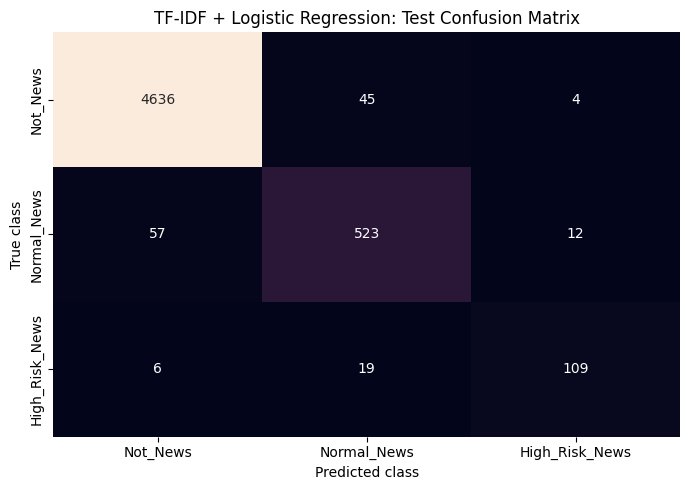

In [18]:
# Confusion matrix for the final held-out test evaluation

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1, 2]
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_df)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cbar=False
)

plt.title('TF-IDF + Logistic Regression: Test Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.tight_layout()

plt.show()

### Final Test Performance

The final TF-IDF + Logistic Regression model achieved a test accuracy of 0.9736 and a macro-F1 of 0.9057 on the previously unseen test partition. The difference between accuracy and macro-F1 reflects the strong class imbalance in the corpus and reinforces the importance of evaluating class-specific performance rather than relying on accuracy alone.

Performance was strongest for `Not_News`, with an F1 score of 0.9881. The model also achieved an F1 score of 0.8872 for `Normal_News`. Performance was lower for the minority `High_Risk_News` class, where precision reached 0.8720, recall reached 0.8134 and F1 reached 0.8417.

The confusion matrix shows that the principal error involving `High_Risk_News` occurs between the two news-oriented categories: 19 of the 134 high-risk observations were classified as `Normal_News`, while only six were classified as `Not_News`. This suggests that the lexical baseline is generally able to distinguish threat-related reporting from unrelated discussion, but has greater difficulty separating routine cybersecurity reporting from genuinely high-risk threat reporting.

A similar boundary is visible for `Normal_News`, where 57 observations were classified as `Not_News` and 12 as `High_Risk_News`. In contrast, the majority `Not_News` class was classified with very high reliability, with 4,636 of 4,685 test observations correctly identified.

Overall, the results establish a strong classical lexical baseline for subsequent comparison with the BERT classifier. The same frozen test observations will be used in the companion BERT notebook so that differences in predictive performance can be attributed to the modelling approach rather than to differences in the evaluation sample.

## 8. Uncertainty Quantification - Bootstrap Confidence Intervals

The metrics reported above are point estimates obtained from a single held-out test sample. This is particularly important for `High_Risk_News`, which contains only 134 test observations and therefore has greater uncertainty than the substantially larger `Not_News` class.

To quantify sampling uncertainty, non-parametric bootstrap confidence intervals are calculated for macro-F1 and each class-specific F1 score. The 5,411 test observations are resampled with replacement 2,000 times, and the relevant F1 scores are recomputed from the stored test labels and predictions for each resample. The 2.5th and 97.5th percentiles of the bootstrap distributions are reported as 95% confidence intervals.

The classifier is not retrained during this procedure; the bootstrap therefore quantifies uncertainty associated with the held-out evaluation sample rather than variability arising from model retraining. Equivalent uncertainty estimates can subsequently be produced for BERT, while direct comparison between the two models can use their predictions on the same frozen test observations.

In [19]:
from sklearn.metrics import f1_score

def bootstrap_f1_intervals(
    y_true,
    y_pred,
    n_boot=2000,
    seed=SEED
):
    """
    Estimate bootstrap confidence intervals for macro-F1
    and class-specific F1 scores using stored test predictions.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rng = np.random.default_rng(seed)
    indices = np.arange(len(y_true))

    bootstrap_scores = {
        'Macro F1': [],
        'Not_News': [],
        'Normal_News': [],
        'High_Risk_News': []
    }

    for _ in range(n_boot):

        sample_idx = rng.choice(
            indices,
            size=len(indices),
            replace=True
        )

        y_boot = y_true[sample_idx]
        pred_boot = y_pred[sample_idx]

        # Macro-F1 across the three fixed target classes
        bootstrap_scores['Macro F1'].append(
            f1_score(
                y_boot,
                pred_boot,
                labels=[0, 1, 2],
                average='macro',
                zero_division=0
            )
        )

        # Class-specific F1 scores
        per_class_f1 = f1_score(
            y_boot,
            pred_boot,
            labels=[0, 1, 2],
            average=None,
            zero_division=0
        )

        bootstrap_scores['Not_News'].append(
            per_class_f1[0]
        )
        bootstrap_scores['Normal_News'].append(
            per_class_f1[1]
        )
        bootstrap_scores['High_Risk_News'].append(
            per_class_f1[2]
        )

    ci_rows = []

    point_estimates = {
        'Macro F1': test_macro_f1,
        'Not_News': report_dict['Not_News']['f1-score'],
        'Normal_News': report_dict['Normal_News']['f1-score'],
        'High_Risk_News': report_dict['High_Risk_News']['f1-score']
    }

    for metric, scores in bootstrap_scores.items():

        scores = np.asarray(scores)

        ci_rows.append({
            'Metric': metric,
            'Point estimate': point_estimates[metric],
            'Bootstrap median': np.median(scores),
            '95% CI lower': np.percentile(scores, 2.5),
            '95% CI upper': np.percentile(scores, 97.5)
        })

    return pd.DataFrame(ci_rows)


bootstrap_ci_df = bootstrap_f1_intervals(
    y_test,
    test_pred,
    n_boot=2000,
    seed=SEED
)

display(
    bootstrap_ci_df.style.format({
        'Point estimate': '{:.4f}',
        'Bootstrap median': '{:.4f}',
        '95% CI lower': '{:.4f}',
        '95% CI upper': '{:.4f}'
    })
)

,Metric,Point estimate,Bootstrap median,95% CI lower,95% CI upper
0,Macro F1,0.9057,0.9055,0.8854,0.9227
1,Not_News,0.9881,0.9881,0.9859,0.9901
2,Normal_News,0.8872,0.8870,0.8676,0.9049
3,High_Risk_News,0.8417,0.8415,0.7895,0.8850


### Bootstrap Confidence Interval Results

The bootstrap analysis places the test macro-F1 estimate of 0.9057 within a 95% confidence interval of [0.8854, 0.9227]. The bootstrap median of 0.9055 is very close to the observed point estimate, indicating that the reported macro-F1 is not driven by an unusual characteristic of the particular test sample.

Uncertainty differs substantially across classes. `Not_News` has the narrowest interval, with an F1 score of 0.9881 and a 95% confidence interval of [0.9859, 0.9901], reflecting the large number of test observations available for this class. `Normal_News` achieves an F1 score of 0.8872 with a 95% confidence interval of [0.8676, 0.9049].

The greatest uncertainty is observed for `High_Risk_News`, whose F1 score of 0.8417 has a wider 95% confidence interval of [0.7895, 0.8850]. This is consistent with the substantially smaller test support of 134 observations and indicates that performance estimates for the minority high-risk class should be interpreted with greater caution.

These intervals quantify uncertainty in the baseline's held-out test performance. Direct statistical comparison with BERT is deferred until predictions from both models are available for the same frozen test observations.

## 9. Test-Set Error Analysis

Overall macro-F1 provides a useful summary of performance, but it does not reveal the types of examples that remain difficult for the classifier. The final test predictions are therefore inspected to identify systematic sources of error, particularly for the `High_Risk_News` class.

The error analysis is performed only after the final model has been selected and evaluated on the frozen test set. It is descriptive only; no model configuration, preprocessing decision or hyperparameter is changed in response to the observed test-set errors.

In [20]:
# Test-set error analysis

# Obtain class probabilities from the already-fitted final model
test_probabilities = final_lr.predict_proba(
    X_test_tfidf
)

error_df = pd.DataFrame({
    'row_id': test_idx,
    'true_label': [
        ID2LABEL[int(x)]
        for x in y_test
    ],
    'predicted_label': [
        ID2LABEL[int(x)]
        for x in test_pred
    ],
    'prediction_confidence': np.max(
        test_probabilities,
        axis=1
    ),
    'text': df.loc[
        test_idx,
        'text'
    ].to_numpy()
})

error_df['correct'] = (
    error_df['true_label']
    ==
    error_df['predicted_label']
)

errors_only = (
    error_df[
        ~error_df['correct']
    ]
    .sort_values(
        'prediction_confidence',
        ascending=False
    )
    .reset_index(drop=True)
)

error_rate = (
    len(errors_only)
    / len(error_df)
)

error_overview = pd.DataFrame({
    'Measure': [
        'Total test observations',
        'Correct predictions',
        'Incorrect predictions',
        'Error rate (%)'
    ],
    'Value': [
        len(error_df),
        int(error_df['correct'].sum()),
        len(errors_only),
        round(error_rate * 100, 2)
    ]
})

display(error_overview)

,Measure,Value
0,Total test observations,5411.00
1,Correct predictions,5268.00
2,Incorrect predictions,143.00
3,Error rate (%),2.64


In [21]:
# Misclassification directions

error_patterns = (
    errors_only
    .groupby(
        ['true_label', 'predicted_label']
    )
    .size()
    .reset_index(name='Count')
    .rename(columns={
        'true_label': 'True class',
        'predicted_label': 'Predicted class'
    })
    .sort_values(
        'Count',
        ascending=False
    )
    .reset_index(drop=True)
)

display(error_patterns)

,True class,Predicted class,Count
0,Normal_News,Not_News,57
1,Not_News,Normal_News,45
2,High_Risk_News,Normal_News,19
3,Normal_News,High_Risk_News,12
4,High_Risk_News,Not_News,6
5,Not_News,High_Risk_News,4


In [22]:
# Highest-confidence test-set errors

high_confidence_errors = (
    errors_only[
        [
            'true_label',
            'predicted_label',
            'prediction_confidence',
            'text'
        ]
    ]
    .head(15)
    .copy()
)

display(
    high_confidence_errors.style.format({
        'prediction_confidence': '{:.4f}'
    })
)

,true_label,predicted_label,prediction_confidence,text
0,Not_News,Normal_News,1.0000,"""Cybercriminals target metaverse investors with phishing scams - check out this piece from our @CNBCinvestigate team and @EamonJavers"
1,Not_News,Normal_News,0.9999,Threat Intelligence update (Data Leak166) Conti Ransomware Gang claims data leak of Hochschild Mining https://t.co/aiDmb7tVGr https://t.co/lVQVXx0QCY
2,Normal_News,Not_News,0.9999,"Per @PeckShieldAlert, @GunslingersNFT discord has been compromised. gunslingersnft[.]org is a phishing link; Sport Move is a scam, $SPORT drops -94%. #Move2Earn; $Libre drops -93% @LibreDeFi https://t.co/FfjQPAMEdJ"""
3,Not_News,Normal_News,0.9998,"#Lockbit claims to have hacked IHG Hotels and Resorts 🏩, allegedly taking guest information and billing data... #Ransomware #RansomwareGroup https://t.co/LoXDoimmlB"
4,High_Risk_News,Normal_News,0.9994,Threat Intelligence update (Data Leak342) Black Basta Ransomware Gang claims data leak of New Peoples Bank https://t.co/0jC6NUsSFC https://t.co/4FjNEjpGIZ
5,Normal_News,Not_News,0.9993,"Week in review: Lapsus$ breaches Okta and Microsoft, Red Team 101 https://t.co/HXmbB2ld02 #DataSecurity #Privacy #100DaysOfCode #Cloud #Security #MachineLearning #Phishing #Ransomware #Cybersecurity #CyberAttacks #DataProtection #Malware #Hacked #infosec https://t.co/2h7zVvNJuW"
6,High_Risk_News,Not_News,0.9993,"""New Microsoft Zero-Day Attack Underway: """"Follina"""" vulnerability in Microsoft Support Diagnostic Tool (MSDT) affects all currently supported Windows versions and can be triggered via specially crafted Office documents. https://t.co/fKfOEf2VGF https://t.co/5BwwHvFUfe"""
7,Normal_News,Not_News,0.9990,"BREAKING: At least two people have died and several have been injured this morning in an attack with a Moroccan military #drone in the town of Ain Bentili, which is on the border between Western Sahara and Mauritania. via @europapress https://t.co/UTQBw3uXdg"
8,Normal_News,Not_News,0.9990,The stats are collated by NCC Group&#039;s dedicated Strategic Threat Intelligence team. It&#039;s key findings revealed that the number of victims of ... #cybernews #thecybernewsfeed https://t.co/3wtIqv6YG4
9,Not_News,Normal_News,0.9987,"Following recent attacks on Nvidia and Samsung, ransomware group now claims to have breached Microsoft: https://t.co/bm3T7jO2Y0"


### Error Analysis Findings

The final baseline makes 143 errors across 5,411 test observations, corresponding to an error rate of 2.64%. The most frequent error direction is `Normal_News → Not_News` (57 cases), followed by `Not_News → Normal_News` (45 cases). These two directions account for the majority of all test-set errors, indicating that the principal difficulty lies in separating routine cybersecurity reporting from more general or non-news discussion.

For `High_Risk_News`, 19 observations are classified as `Normal_News`, whereas only six are classified as `Not_News`. This supports the pattern observed in the confusion matrix: the lexical model generally recognises high-risk examples as cybersecurity-related content but has greater difficulty distinguishing urgent threat reporting from routine cybersecurity news.

Inspection of the highest-probability errors also reveals several lexically plausible misclassifications. Tweets containing terms such as *ransomware*, *data leak*, *attack*, *phishing* and named threat groups may receive strong predictions for a news-oriented class even when their annotated label differs. This illustrates a limitation of the TF-IDF representation: strongly weighted lexical cues can dominate the prediction without modelling the wider contextual meaning of the tweet.

The reported prediction confidence corresponds to the maximum class probability produced by Logistic Regression and should not be interpreted as a calibrated probability of correctness. The error analysis is descriptive only and is not used to modify the already-evaluated model.

## 10. Persistence of Predictions and Metadata

The final held-out test predictions and class probabilities are persisted using the original dataset row indices. A separate metadata record stores the frozen test-set checksum, selected TF-IDF and Logistic Regression configuration, final validation and test metrics, bootstrap confidence intervals, and software environment information.

These artefacts support reproducibility and enable direct comparison with the companion BERT notebook. In particular, retaining the row identifiers allows predictions from both models to be aligned on the same frozen test observations for subsequent paired statistical comparison and cross-model analysis.

In [23]:
import json

# Persist final baseline test predictions and probabilities

test_pred_df = pd.DataFrame({
    'row_id': test_idx,
    'true_label': y_test,
    'baseline_pred': test_pred,
    'prob_Not_News': test_probabilities[:, 0],
    'prob_Normal_News': test_probabilities[:, 1],
    'prob_High_Risk_News': test_probabilities[:, 2]
})

test_pred_df.to_csv(
    'baseline_test_predictions.csv',
    index=False
)

# Extract bootstrap confidence intervals

ci_lookup = (
    bootstrap_ci_df
    .set_index('Metric')
)

# Persist modelling metadata

meta = {
    'split_checksum': split_checksum,

    'best_params': {
        'C': float(best_C),
        'ngram_range': list(best_ngram_range),
        'max_features': int(representation_max_features),
        'min_df': int(representation_min_df),
        'sublinear_tf': bool(representation_sublinear),
        'class_weight': best_class_weight
    },

    'validation_macro_f1': round(
        float(
            class_weight_results_df.iloc[0][
                'Validation Macro-F1'
            ]
        ),
        4
    ),

    'test_metrics': {
        'accuracy': round(
            float(test_accuracy),
            4
        ),
        'macro_precision': round(
            float(test_macro_precision),
            4
        ),
        'macro_recall': round(
            float(test_macro_recall),
            4
        ),
        'macro_f1': round(
            float(test_macro_f1),
            4
        )
    },

    'test_f1_95ci': {
        'Macro F1': [
            round(
                float(
                    ci_lookup.loc[
                        'Macro F1',
                        '95% CI lower'
                    ]
                ),
                4
            ),
            round(
                float(
                    ci_lookup.loc[
                        'Macro F1',
                        '95% CI upper'
                    ]
                ),
                4
            )
        ],

        'Not_News': [
            round(
                float(
                    ci_lookup.loc[
                        'Not_News',
                        '95% CI lower'
                    ]
                ),
                4
            ),
            round(
                float(
                    ci_lookup.loc[
                        'Not_News',
                        '95% CI upper'
                    ]
                ),
                4
            )
        ],

        'Normal_News': [
            round(
                float(
                    ci_lookup.loc[
                        'Normal_News',
                        '95% CI lower'
                    ]
                ),
                4
            ),
            round(
                float(
                    ci_lookup.loc[
                        'Normal_News',
                        '95% CI upper'
                    ]
                ),
                4
            )
        ],

        'High_Risk_News': [
            round(
                float(
                    ci_lookup.loc[
                        'High_Risk_News',
                        '95% CI lower'
                    ]
                ),
                4
            ),
            round(
                float(
                    ci_lookup.loc[
                        'High_Risk_News',
                        '95% CI upper'
                    ]
                ),
                4
            )
        ]
    },

    'environment': {
        'python': sys.version.split()[0],
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'sklearn': sklearn.__version__,
        'seed': SEED
    }
}

with open(
    'baseline_meta.json',
    'w'
) as f:

    json.dump(
        meta,
        f,
        indent=2
    )

print(
    "Saved: baseline_test_predictions.csv, "
    "baseline_meta.json"
)

print(
    json.dumps(
        meta,
        indent=2
    )
)

Saved: baseline_test_predictions.csv, baseline_meta.json
{
  "split_checksum": "879a8be1c2ee",
  "best_params": {
    "C": 100.0,
    "ngram_range": [
      1,
      3
    ],
    "max_features": 100000,
    "min_df": 1,
    "sublinear_tf": true,
    "class_weight": null
  },
  "validation_macro_f1": 0.8949,
  "test_metrics": {
    "accuracy": 0.9736,
    "macro_precision": 0.9165,
    "macro_recall": 0.8955,
    "macro_f1": 0.9057
  },
  "test_f1_95ci": {
    "Macro F1": [
      0.8854,
      0.9227
    ],
    "Not_News": [
      0.9859,
      0.9901
    ],
    "Normal_News": [
      0.8676,
      0.9049
    ],
    "High_Risk_News": [
      0.7895,
      0.885
    ]
  },
  "environment": {
    "python": "3.12.13",
    "numpy": "2.0.2",
    "pandas": "2.3.3",
    "sklearn": "1.6.1",
    "seed": 42
  }
}


## 11. Coefficient-Based Model Interpretation

Logistic Regression provides an intrinsically interpretable lexical reference because each TF-IDF feature is associated with a class-specific model coefficient. For a given class, a larger positive coefficient indicates that the corresponding lexical feature contributes more strongly toward that class prediction, conditional on the other features represented by the model.

The strongest positive coefficients are therefore examined for `Not_News`, `Normal_News` and `High_Risk_News`. To reduce the influence of highly specific features occurring in only a handful of documents, interpretation is restricted to features appearing in at least 20 observations within the combined training and validation data used to estimate the final baseline.

This analysis provides a transparent account of the lexical cues used by the TF-IDF + Logistic Regression baseline. It does not answer RQ2, which concerns class-specific SHAP explanations for BERT. Instead, the coefficient rankings provide the classical-model lexical reference required for the later cross-model analysis in RQ4, where Logistic Regression features are compared with important tokens identified from BERT explanations.

Coefficient magnitude is interpreted as model-specific feature influence rather than causal importance. The rankings therefore describe lexical associations learned by the fitted classifier and should not be interpreted as evidence that individual terms inherently determine cybersecurity risk.

In [24]:
# Coefficient-based interpretation of the final Logistic Regression baseline

feature_names = np.array(
    final_vectorizer.get_feature_names_out()
)

# Number of train + validation documents in which each TF-IDF feature occurs
doc_freq = np.asarray(
    (X_trainval_tfidf > 0).sum(axis=0)
).ravel()

MIN_DF_INTERPRET = 20
N_DISPLAY = 15
N_EXPORT = 50

coefficient_rows = []

for class_position, class_id in enumerate(final_lr.classes_):

    class_name = ID2LABEL[int(class_id)]
    coefficients = final_lr.coef_[class_position]

    # Restrict interpretation to features appearing in at least
    # MIN_DF_INTERPRET development documents
    eligible_idx = np.where(
        doc_freq >= MIN_DF_INTERPRET
    )[0]

    ranked_idx = eligible_idx[
        np.argsort(
            coefficients[eligible_idx]
        )[::-1]
    ]

    for rank, feature_idx in enumerate(
        ranked_idx[:N_EXPORT],
        start=1
    ):
        coefficient_rows.append({
            'Class': class_name,
            'Rank': rank,
            'Feature': feature_names[feature_idx],
            'Coefficient': coefficients[feature_idx],
            'Document frequency': int(
                doc_freq[feature_idx]
            )
        })

coefficient_rankings = pd.DataFrame(
    coefficient_rows
)

display(
    coefficient_rankings.groupby(
        'Class',
        sort=False
    ).head(N_DISPLAY).style.format({
        'Coefficient': '{:.4f}'
    })
)

,Class,Rank,Feature,Coefficient,Document frequency
0,Not_News,1,learn,7.3831,885
1,Not_News,2,worms,7.0873,711
2,Not_News,3,protect,7.0657,746
3,Not_News,4,like,7.0522,1022
4,Not_News,5,know,6.7847,759
5,Not_News,6,get,6.4564,1011
6,Not_News,7,ransomware,6.1324,15964
7,Not_News,8,need,6.0431,700
8,Not_News,9,honeypot,6.0054,504
9,Not_News,10,phishing,5.9859,7169


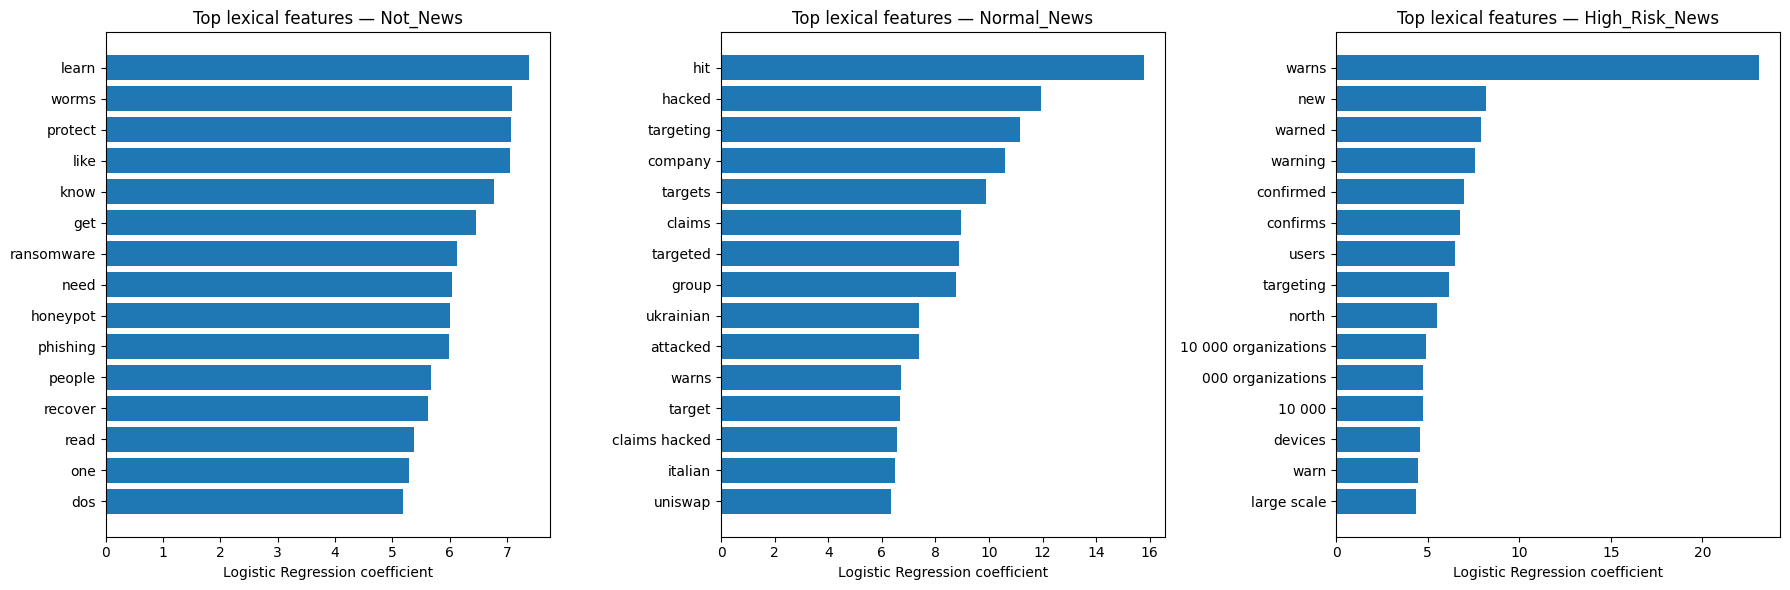

In [25]:
# Visualise the strongest positive coefficients for each class

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for ax, class_name in zip(
    axes,
    CLASS_NAMES
):

    class_terms = (
        coefficient_rankings[
            coefficient_rankings['Class']
            == class_name
        ]
        .head(N_DISPLAY)
        .sort_values(
            'Coefficient',
            ascending=True
        )
    )

    ax.barh(
        class_terms['Feature'],
        class_terms['Coefficient']
    )

    ax.set_title(
        f'Top lexical features — {class_name}'
    )

    ax.set_xlabel(
        'Logistic Regression coefficient'
    )

plt.tight_layout()
plt.show()

In [26]:
# Persist coefficient rankings for later cross-model comparison

coefficient_rankings.to_csv(
    'baseline_coefficient_rankings.csv',
    index=False
)

print(
    "Saved: baseline_coefficient_rankings.csv"
)

Saved: baseline_coefficient_rankings.csv


### Investigation of the High-Weight Feature `warns`

In [27]:
# Investigation of the unusually high-weight feature "warns"

target_term = 'warns'

if target_term in final_vectorizer.vocabulary_:

    target_index = final_vectorizer.vocabulary_[target_term]

    coefficient_rows_warns = []

    for class_position, class_id in enumerate(final_lr.classes_):

        coefficient_rows_warns.append({
            'Class': ID2LABEL[int(class_id)],
            'Coefficient': final_lr.coef_[
                class_position,
                target_index
            ]
        })

    warns_coefficients = pd.DataFrame(
        coefficient_rows_warns
    )

    display(
        warns_coefficients.style.format({
            'Coefficient': '{:.4f}'
        })
    )

    warns_mask = (
        df['clean_text']
        .fillna('')
        .str.contains(
            r'\bwarns\b',
            regex=True
        )
    )

    warns_distribution = (
        df.loc[warns_mask, 'majority']
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
        .rename_axis('Class')
        .reset_index(name='Tweets containing warns')
    )

    warns_distribution['Percentage'] = (
        warns_distribution['Tweets containing warns']
        / warns_distribution['Tweets containing warns'].sum()
        * 100
    ).round(2)

    print(
        f"Total observations containing 'warns': "
        f"{int(warns_mask.sum()):,}"
    )

    display(warns_distribution)

else:
    print(
        "'warns' is not present in the final TF-IDF vocabulary."
    )

,Class,Coefficient
0,Not_News,-29.8084
1,Normal_News,6.7244
2,High_Risk_News,23.0841


Total observations containing 'warns': 706


,Class,Tweets containing warns,Percentage
0,Not_News,50,7.08
1,Normal_News,135,19.12
2,High_Risk_News,521,73.80


### Interpretation of the High-Weight `warns` Feature

The coefficient analysis identifies `warns` as the strongest displayed positive lexical feature for `High_Risk_News`, with a substantially larger coefficient than the remaining high-risk features. A supplementary corpus-level inspection was therefore conducted to determine whether this unusually strong model weight corresponds to an observable class association.

Across the full corpus, 706 observations contain the token `warns`. Of these, 521 (73.80%) are labelled `High_Risk_News`, compared with 135 (19.12%) labelled `Normal_News` and 50 (7.08%) labelled `Not_News`. This strong concentration within the high-risk class provides a plausible explanation for the large positive coefficient learned by Logistic Regression.

The document frequency reported in the coefficient ranking (602) refers specifically to the combined training and validation data on which the final classifier was estimated, whereas the 706 observations reported in this diagnostic refer to the complete corpus.

The result should nevertheless be interpreted as a dataset-specific lexical association rather than evidence that the word `warns` inherently indicates high cybersecurity risk. The prominence of warning-related terms (`warns`, `warned`, `warning` and `warn`) also illustrates the lexical nature of the baseline: Logistic Regression can place substantial weight on recurring surface-level language associated with class labels. Whether the contextual BERT model relies on similar lexical cues is examined later through the cross-model comparison in RQ4.

## 12. Cross-Partition Similarity Audit

The earlier duplicate audit identified exact duplicate text observations before dataset partitioning. However, social-media corpora may also contain near-duplicate posts that differ only slightly in wording, formatting, URLs or other surface-level elements. If highly similar observations appear across the training and evaluation partitions, measured test performance may partly reflect repeated or near-repeated content rather than generalisation to genuinely distinct examples.

A post-hoc cross-partition similarity audit is therefore performed using character-level TF-IDF features, which are sensitive to small textual variations while remaining robust to minor token-level differences. For each observation, the most similar observations from the other dataset partitions are examined using cosine similarity.

This audit is diagnostic only and is conducted after final model evaluation. No observations are removed and no model configuration is changed in response to the similarity results. The purpose is to document the extent of potential cross-partition redundancy and to support cautious interpretation of the reported performance.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Character-level representation for similarity auditing

audit_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000
)

audit_matrix = audit_vectorizer.fit_transform(
    df['clean_text'].fillna('')
)

# Partition membership
partition_lookup = {}

for idx in train_idx:
    partition_lookup[int(idx)] = 'Train'

for idx in val_idx:
    partition_lookup[int(idx)] = 'Validation'

for idx in test_idx:
    partition_lookup[int(idx)] = 'Test'

# Request several neighbours so that a same-partition nearest neighbour
# does not prevent detection of a highly similar cross-partition match.
N_NEIGHBOURS = 10

nearest = NearestNeighbors(
    n_neighbors=N_NEIGHBOURS,
    metric='cosine',
    n_jobs=-1
)

nearest.fit(audit_matrix)

distances, neighbours = nearest.kneighbors(
    audit_matrix
)

near_duplicate_rows = []

for row_position in range(len(df)):

    source_partition = partition_lookup[row_position]

    for neighbour_position, distance in zip(
        neighbours[row_position, 1:],
        distances[row_position, 1:]
    ):

        neighbour_position = int(neighbour_position)
        neighbour_partition = partition_lookup[
            neighbour_position
        ]

        # Only consider observations from another partition
        if neighbour_partition == source_partition:
            continue

        similarity = 1.0 - float(distance)

        if similarity >= 0.90:

            # Store each unordered pair only once
            row_a = min(
                row_position,
                neighbour_position
            )
            row_b = max(
                row_position,
                neighbour_position
            )

            near_duplicate_rows.append({
                'row_id_1': row_a,
                'row_id_2': row_b,
                'partition_1': partition_lookup[row_a],
                'partition_2': partition_lookup[row_b],
                'cosine_similarity': similarity,
                'label_1': df.loc[row_a, 'majority'],
                'label_2': df.loc[row_b, 'majority']
            })

# Remove duplicate pair records
near_duplicate_df = (
    pd.DataFrame(near_duplicate_rows)
    .drop_duplicates(
        subset=['row_id_1', 'row_id_2']
    )
    .sort_values(
        'cosine_similarity',
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Unique cross-partition pairs with "
    "cosine similarity >= 0.90: "
    f"{len(near_duplicate_df):,}"
)

display(
    near_duplicate_df.head(20)
)

Unique cross-partition pairs with cosine similarity >= 0.90: 17,996


,row_id_1,row_id_2,partition_1,partition_2,cosine_similarity,label_1,label_2
0,35371,36059,Test,Train,1.0,Normal_News,Normal_News
1,5,4306,Validation,Train,1.0,Not_News,Not_News
2,5,7392,Validation,Train,1.0,Not_News,Not_News
3,5,4342,Validation,Test,1.0,Not_News,Not_News
4,5,3810,Validation,Train,1.0,Not_News,Not_News
5,5,4350,Validation,Train,1.0,Not_News,Not_News
6,5,2570,Validation,Test,1.0,Not_News,Not_News
7,5,1027,Validation,Test,1.0,Not_News,Not_News
8,5,10161,Validation,Train,1.0,Not_News,Not_News
9,33940,36039,Train,Validation,1.0,Normal_News,Normal_News


In [29]:
# Summary of high-similarity cross-partition pairs

if len(near_duplicate_df) > 0:

    similarity_summary = pd.DataFrame({
        'Measure': [
            'Pairs with similarity >= 0.90',
            'Pairs with similarity >= 0.95',
            'Pairs with similarity >= 0.99',
            'Pairs with identical labels',
            'Pairs with different labels'
        ],
        'Count': [
            len(near_duplicate_df),
            int(
                (
                    near_duplicate_df[
                        'cosine_similarity'
                    ] >= 0.95
                ).sum()
            ),
            int(
                (
                    near_duplicate_df[
                        'cosine_similarity'
                    ] >= 0.99
                ).sum()
            ),
            int(
                (
                    near_duplicate_df['label_1']
                    ==
                    near_duplicate_df['label_2']
                ).sum()
            ),
            int(
                (
                    near_duplicate_df['label_1']
                    !=
                    near_duplicate_df['label_2']
                ).sum()
            )
        ]
    })

    display(similarity_summary)

else:

    print(
        "No high-similarity cross-partition pairs "
        "were detected."
    )

,Measure,Count
0,Pairs with similarity >= 0.90,17996
1,Pairs with similarity >= 0.95,15414
2,Pairs with similarity >= 0.99,12999
3,Pairs with identical labels,17666
4,Pairs with different labels,330


In [30]:
# Test-to-training similarity exposure audit

# Fit an audit representation using training data only
train_audit_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000
)

X_train_audit = train_audit_vectorizer.fit_transform(
    df.loc[train_idx, 'clean_text'].fillna('')
)

X_test_audit = train_audit_vectorizer.transform(
    df.loc[test_idx, 'clean_text'].fillna('')
)

# Find the single most similar training observation
# for every held-out test observation
train_nn = NearestNeighbors(
    n_neighbors=1,
    metric='cosine',
    n_jobs=-1
)

train_nn.fit(X_train_audit)

test_distances, test_neighbours = train_nn.kneighbors(
    X_test_audit
)

test_max_similarity = 1.0 - test_distances.ravel()

test_similarity_df = pd.DataFrame({
    'test_row_id': test_idx,
    'nearest_train_row_id': train_idx[
        test_neighbours.ravel()
    ],
    'max_train_similarity': test_max_similarity
})

test_similarity_df['test_label'] = (
    df.loc[
        test_similarity_df['test_row_id'],
        'majority'
    ].to_numpy()
)

test_similarity_df['train_label'] = (
    df.loc[
        test_similarity_df['nearest_train_row_id'],
        'majority'
    ].to_numpy()
)

test_similarity_summary = pd.DataFrame({
    'Threshold': [
        '>= 0.90',
        '>= 0.95',
        '>= 0.99',
        '= 1.00'
    ],
    'Test observations': [
        int((test_max_similarity >= 0.90).sum()),
        int((test_max_similarity >= 0.95).sum()),
        int((test_max_similarity >= 0.99).sum()),
        int(np.isclose(test_max_similarity, 1.0).sum())
    ]
})

test_similarity_summary['Percentage of test set'] = (
    test_similarity_summary['Test observations']
    / len(test_idx)
    * 100
).round(2)

display(test_similarity_summary)

,Threshold,Test observations,Percentage of test set
0,>= 0.90,1493,27.59
1,>= 0.95,1319,24.38
2,>= 0.99,1155,21.35
3,= 1.00,1143,21.12


### Cross-Partition Similarity Findings

The similarity audit reveals substantial lexical redundancy between the training and held-out test partitions. Of the 5,411 test observations, 1,493 (27.59%) have at least one training observation with character-level cosine similarity of 0.90 or greater. This decreases to 1,319 observations (24.38%) at a threshold of 0.95 and 1,155 observations (21.35%) at 0.99. A total of 1,143 test observations (21.12%) have a nearest training observation with cosine similarity effectively equal to 1.00 under the audit representation.

These results indicate that the corpus contains a substantial amount of highly repetitive or templated lexical content across the randomly stratified partitions. This should not be interpreted as evidence of procedural data leakage, because the partitions were generated independently using fixed stratified sampling and the audit was performed only after model evaluation. Rather, it reflects redundancy within the underlying social-media corpus.

Nevertheless, the finding is an important limitation of the evaluation design. Test observations that closely resemble training observations may be easier for a lexical classifier to recognise, meaning that the reported test performance may overestimate generalisation to completely novel cybersecurity posts. The test results should therefore be interpreted as performance under the predefined random stratified split rather than as an estimate of performance on a fully deduplicated or temporally independent corpus.

No observations are removed and the model is not retrained in response to this post-hoc audit. Altering the evaluation set after observing the final test results would compromise the predefined experimental protocol. The same frozen test partition is retained for BERT so that the comparison required for RQ1 remains controlled and directly comparable across models.

## 13. Final Baseline Summary and Handover to BERT

The final classical baseline uses TF-IDF features with unigram-to-trigram representations and Logistic Regression. Model development was performed using the predefined training and validation partitions, while the held-out test partition remained untouched until the final evaluation stage.

The selected configuration achieved a validation macro-F1 of 0.8949 and a held-out test macro-F1 of 0.9057. Performance was strongest for `Not_News`, while `High_Risk_News` remained the most challenging class. Bootstrap analysis placed the test macro-F1 within a 95% confidence interval of [0.8854, 0.9227].

The coefficient analysis provides an interpretable lexical reference for the baseline, while the persisted test predictions, class probabilities, coefficient rankings and split metadata support later comparison with BERT. The companion notebook must reproduce the same frozen test partition, identified by checksum `879a8be1c2ee`, so that both models are evaluated on identical observations.

The baseline therefore provides the classical reference required for RQ1 and the lexical comparison reference required for the later cross-model analysis in RQ4. RQ2 and RQ3 are addressed in the BERT + SHAP notebook.

In [31]:
# Final baseline summary

final_summary = pd.DataFrame({
    'Item': [
        'Model',
        'C',
        'N-gram range',
        'Max features',
        'Minimum document frequency',
        'Sublinear TF',
        'Class weight',
        'Validation Macro-F1',
        'Test Accuracy',
        'Test Macro Precision',
        'Test Macro Recall',
        'Test Macro-F1',
        'Macro-F1 95% CI',
        'Test-set checksum'
    ],
    'Value': [
        'TF-IDF + Logistic Regression',
        best_C,
        str(best_ngram_range),
        f'{representation_max_features:,}',
        representation_min_df,
        representation_sublinear,
        str(best_class_weight),
        f'{class_weight_results_df.iloc[0]["Validation Macro-F1"]:.4f}',
        f'{test_accuracy:.4f}',
        f'{test_macro_precision:.4f}',
        f'{test_macro_recall:.4f}',
        f'{test_macro_f1:.4f}',
        (
            f'[{ci_lookup.loc["Macro F1", "95% CI lower"]:.4f}, '
            f'{ci_lookup.loc["Macro F1", "95% CI upper"]:.4f}]'
        ),
        split_checksum
    ]
})

display(final_summary)

,Item,Value
0,Model,TF-IDF + Logistic Regression
1,C,100.0
2,N-gram range,"(1, 3)"
3,Max features,"100,000"
4,Minimum document frequency,1
5,Sublinear TF,True
6,Class weight,None
7,Validation Macro-F1,0.8949
8,Test Accuracy,0.9736
9,Test Macro Precision,0.9165


# Baseline Notebook Completion

The TF-IDF + Logistic Regression baseline is now complete. All model-selection decisions were made using the training and validation partitions, with the held-out test set reserved for final evaluation. The resulting test predictions, class probabilities, coefficient rankings and reproducibility metadata have been persisted for subsequent comparison with BERT.

The companion BERT notebook will use the same predefined dataset partition and must reproduce the test-set checksum `879a8be1c2ee`. This ensures that RQ1 compares the two modelling approaches on identical test observations. The Logistic Regression coefficient rankings also provide the lexical reference required for the later cross-model comparison in RQ4, while the BERT + SHAP workflow addresses the token-level explanation and faithfulness analyses required for RQ2 and RQ3.